In [ ]:
import pandas as pd
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path().resolve().parents[0]))

from src.data_loader import load_train_data

train = load_train_data()

Objetivo

El objetivo de este análisis exploratorio es identificar los factores que influyen en el precio de las viviendas en Ames, Iowa, y comprender la estructura y calidad del dataset antes de aplicar modelos predictivos.

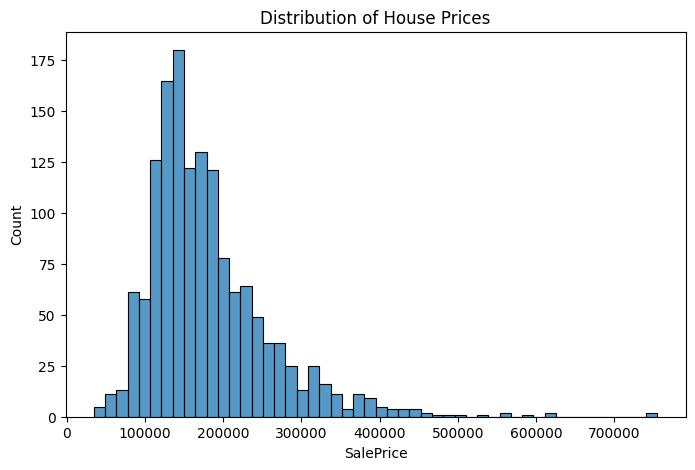

In [2]:
plt.figure(figsize=(8,5))
sns.histplot(train["SalePrice"], bins=50)
plt.title("Distribution of House Prices")
plt.show()

Distribución del precio de las casas

- La distribución de SalePrice está sesgada hacia la derecha.
- La mayoría de las casas se concentran en rangos de precios bajos o medios.
- Existen pocas propiedades de alto valor que generan la cola derecha de la distribución.

Esto sugiere que una transformación logarítmica del precio puede ser útil para modelado.

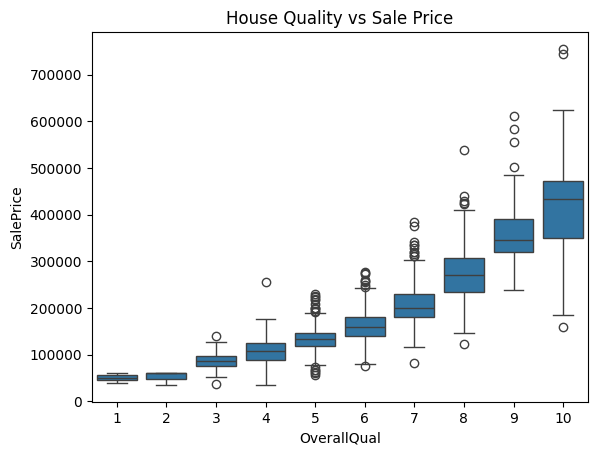

In [3]:
sns.boxplot(x="OverallQual", y="SalePrice", data=train)
plt.title("House Quality vs Sale Price")
plt.show()

La calidad de la casa es el factor más importante

- Existe una relación clara entre calidad general de la casa y precio.
- Casas con mayor calidad tienen precios significativamente mayores.

OverallQual es el predictor más fuerte del precio.

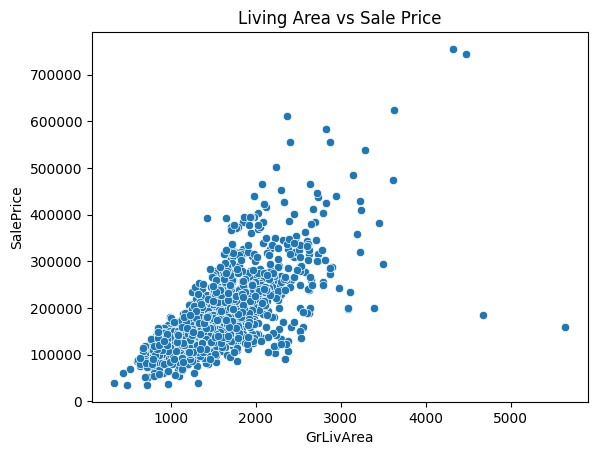

In [4]:
sns.scatterplot(x="GrLivArea", y="SalePrice", data=train)
plt.title("Living Area vs Sale Price")
plt.show()

El tamaño de la casa influye fuertemente

- Existe una fuerte correlación positiva entre área habitable y precio.
- Casas más grandes tienden a tener precios más altos.

El tamaño de la vivienda es uno de los factores económicos más relevantes.

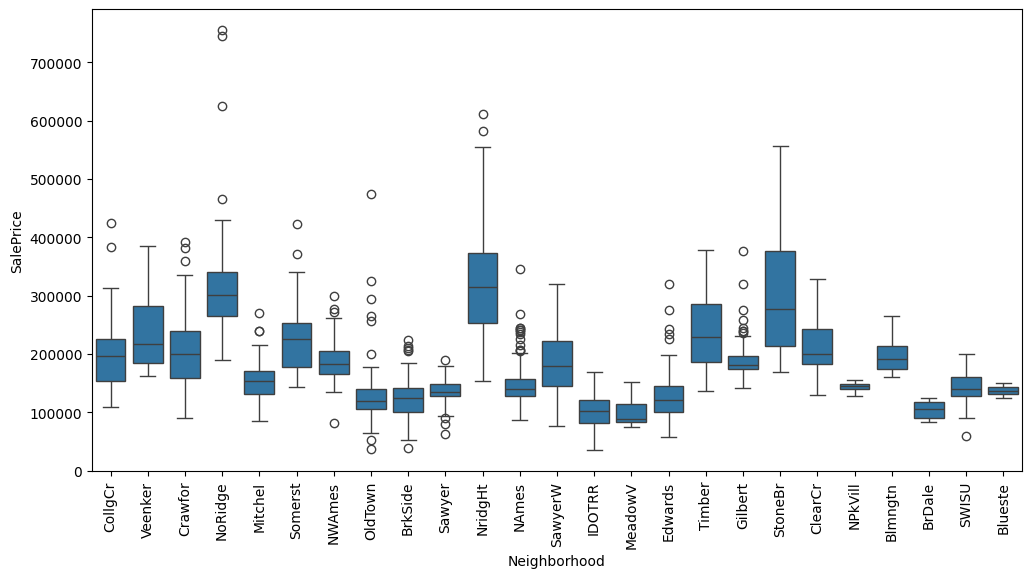

In [5]:
plt.figure(figsize=(12,6))
sns.boxplot(x="Neighborhood", y="SalePrice", data=train)
plt.xticks(rotation=90)
plt.show()

La ubicación también importa

- Existen diferencias importantes de precio entre barrios.
- Algunos barrios presentan precios consistentemente más altos.

La ubicación geográfica influye significativamente en el valor de las propiedades.

In [9]:
corr_matrix = train.corr(numeric_only=True)
saleprice_corr = corr_matrix["SalePrice"].sort_values(ascending=False)

saleprice_corr.head(6)

SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
TotalBsmtSF    0.613581
Name: SalePrice, dtype: float64

Variables relacionadas con tamaño dominan el precio

Muchas de las variables más importantes están relacionadas con:

- Tamaño
- Calidad
- Estructura de la casa

Esto indica que el valor de una vivienda depende principalmente de su calidad estructural y espacio habitable.

In [10]:
train[(train["GrLivArea"] > 4000) & (train["SalePrice"] < 300000)]

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
523,524,60,RL,130.0,40094,Pave,NaN,IR1,Bnk,AllPub,...,0,NaN,NaN,NaN,0,10,2007,New,Partial,184750
1298,1299,60,RL,313.0,63887,Pave,NaN,IR3,Bnk,AllPub,...,480,Gd,NaN,NaN,0,1,2008,New,Partial,160000


Outliers detectados

- Se detectaron dos observaciones con GrLivArea extremadamente alto pero precio bajo.
- Estos puntos distorsionaban la relación entre tamaño y precio.

Se eliminaron observaciones con GrLivArea > 4000. Esto mejora la estabilidad del análisis.

Conclusiones finales

- El análisis exploratorio reveló varios factores clave que influyen en el precio de las viviendas:
- La calidad general de la casa (OverallQual) es el predictor más fuerte.
- El tamaño de la vivienda (GrLivArea) tiene una fuerte relación positiva con el precio.
- Características relacionadas con el tamaño de la casa dominan las correlaciones.
- La ubicación (Neighborhood) introduce diferencias significativas en el valor de las propiedades.
- Se detectaron y eliminaron outliers que distorsionaban algunas relaciones.